<a href="https://colab.research.google.com/github/d12eek/Image-Reconstruction-using-Convolutional-Autoencoders-on-CIFAR-10/blob/main/Image_Reconstruction_using_Convolutional_Autoencoders_on_CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1.Importing Necessary Libraries**

In [1]:
!pip install pytorch-msssim -q

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from pytorch_msssim import ssim

**2.Checking for the GPU**

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

**3.Mount Google Drive and make the data and output folder**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
BASE_DIR   = '/content/drive/MyDrive/CAE_CIFAR10'
DATA_DIR   = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')

os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [6]:
CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("✅ All imports done!")
print(f"📂 Base folder   : {BASE_DIR}")
print(f"📂 Data folder   : {DATA_DIR}")
print(f"📂 Output folder : {OUTPUT_DIR}")
print(f"🖥️  Device        : {device}")

✅ All imports done!
📂 Base folder   : /content/drive/MyDrive/CAE_CIFAR10
📂 Data folder   : /content/drive/MyDrive/CAE_CIFAR10/data
📂 Output folder : /content/drive/MyDrive/CAE_CIFAR10/output
🖥️  Device        : cuda


**4.Load full Cifar-Dataset**

In [7]:
# ============================================================
# Load Full CIFAR-10 Dataset
# ============================================================

# ── Transforms (No Normalization!) ───────────────────────────
transform = transforms.Compose([
    transforms.ToTensor()   # Only convert to [0,1] range
])

# ── Load Training Set (50,000 images) ────────────────────────
train_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,       # Already downloaded!
    transform=transform
)

# ── Load Test Set (10,000 images) ────────────────────────────
test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform
)

# ── DataLoaders ───────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2
)

print("✅ Dataset Reloaded (No Normalization)!")
print(f"📦 Training images : {len(train_dataset):,}")
print(f"📦 Test images     : {len(test_dataset):,}")

✅ Dataset Reloaded (No Normalization)!
📦 Training images : 50,000
📦 Test images     : 10,000


**5.Convolutional Autoencoder Model**

In [8]:
# ============================================================
# Convolutional Autoencoder Model
# ============================================================

class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.encoder = nn.Sequential(
            # Input: (3, 32, 32)
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),    # → (32, 16, 16)
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),   # → (64, 8, 8)
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # → (128, 4, 4)
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

    def forward(self, x):
        return self.encoder(x)


class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.decoder = nn.Sequential(
            # Input: (128, 4, 4)
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2,
                               padding=1, output_padding=1),          # → (64, 8, 8)
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2,
                               padding=1, output_padding=1),          # → (32, 16, 16)
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2,
                               padding=1, output_padding=1),          # → (3, 32, 32)
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(x)


class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


# ── Initialize Model ─────────────────────────────────────────
model     = ConvAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ── Model Summary ────────────────────────────────────────────
total_params   = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Quick shape test
dummy  = torch.randn(1, 3, 32, 32).to(device)
output = model(dummy)

print("✅ Model Ready!")
print(f"🧠 Total Parameters     : {total_params:,}")
print(f"🔧 Trainable Parameters : {trainable_params:,}")
print(f"📥 Input Shape          : {dummy.shape}")
print(f"📤 Output Shape         : {output.shape}")
print(f"📉 Loss Function        : MSELoss")
print(f"⚙️  Optimizer            : Adam (lr=0.001)")

✅ Model Ready!
🧠 Total Parameters     : 187,011
🔧 Trainable Parameters : 187,011
📥 Input Shape          : torch.Size([1, 3, 32, 32])
📤 Output Shape         : torch.Size([1, 3, 32, 32])
📉 Loss Function        : MSELoss
⚙️  Optimizer            : Adam (lr=0.001)


**6.Training the Model**

In [9]:
# ============================================================
# Training Loop
# ============================================================

epochs = 50
train_losses = []

print(f"🔁 Epochs     : {epochs}")
print(f"📦 Batch Size : 128")
print(f"🖥️  Device     : {device}")
print(f"🖼️  Images     : 50,000")
print("\n" + "=" * 50)
print("           TRAINING STARTED")
print("=" * 50)

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        # Forward Pass
        reconstructed = model(images)

        # Compute Loss
        loss = criterion(reconstructed, images)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Print every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch [{epoch:2d}/{epochs}]  →  Loss: {avg_loss:.6f}")

print("=" * 50)
print("✅ Training Complete!")
print(f"📉 Initial Loss : {train_losses[0]:.6f}")
print(f"📉 Final Loss   : {train_losses[-1]:.6f}")
print(f"📉 Improvement  : {((train_losses[0] - train_losses[-1])/train_losses[0])*100:.1f}%")

🔁 Epochs     : 50
📦 Batch Size : 128
🖥️  Device     : cuda
🖼️  Images     : 50,000

           TRAINING STARTED
  Epoch [ 1/50]  →  Loss: 0.008832
  Epoch [ 5/50]  →  Loss: 0.001656
  Epoch [10/50]  →  Loss: 0.001036
  Epoch [15/50]  →  Loss: 0.000864
  Epoch [20/50]  →  Loss: 0.000756
  Epoch [25/50]  →  Loss: 0.000666
  Epoch [30/50]  →  Loss: 0.000611
  Epoch [35/50]  →  Loss: 0.000580
  Epoch [40/50]  →  Loss: 0.000546
  Epoch [45/50]  →  Loss: 0.000496
  Epoch [50/50]  →  Loss: 0.000469
✅ Training Complete!
📉 Initial Loss : 0.008832
📉 Final Loss   : 0.000469
📉 Improvement  : 94.7%


**7.Plot Loss Curve**

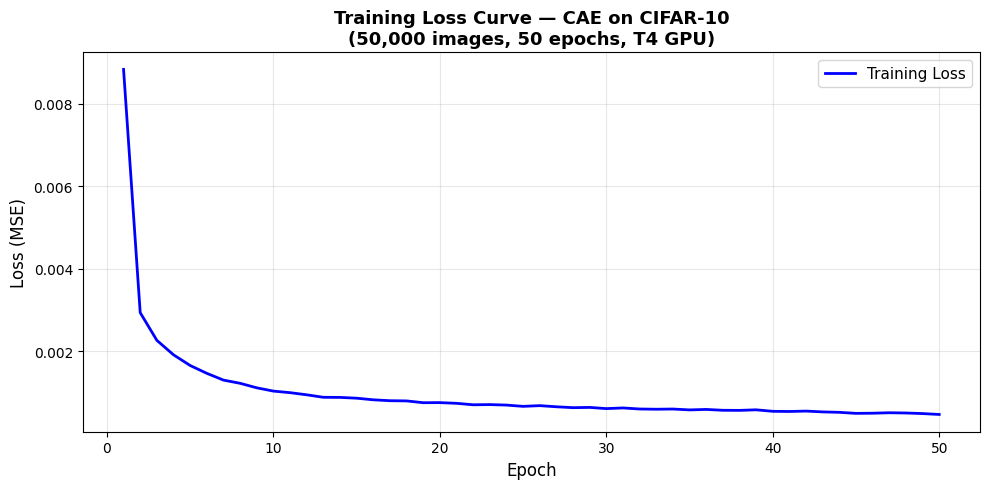

💾 Loss curve saved → /content/drive/MyDrive/CAE_CIFAR10/output/loss_curve.png


In [10]:
# ============================================================
# Plot Loss Curve
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses,
         color='blue', linewidth=2, label='Training Loss')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training Loss Curve — CAE on CIFAR-10\n(50,000 images, 50 epochs, T4 GPU)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save to Drive
loss_curve_path = os.path.join(OUTPUT_DIR, 'loss_curve.png')
plt.savefig(loss_curve_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"💾 Loss curve saved → {loss_curve_path}")

**8.Evalution(MSE and SSIM)**

In [11]:
# ============================================================
# Evaluation (MSE + SSIM)
# ============================================================

model.eval()

# ── Get one batch from test set ──────────────────────────────
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)

with torch.no_grad():
    reconstructed = model(test_images)

# Move to CPU
images_cpu = test_images.cpu()
recon_cpu  = reconstructed.cpu()

# ── Compute Scores Per Class ─────────────────────────────────
print("\n📊 Evaluation on Test Set:")
print("=" * 60)
print(f"  {'Class':<12} {'MSE':>10} {'SSIM':>10} {'Quality':>12}")
print("=" * 60)

mse_scores  = []
ssim_scores = []

for i in range(len(images_cpu)):
    mse = torch.mean((images_cpu[i] - recon_cpu[i]) ** 2).item()

    ssim_score = ssim(
        images_cpu[i].unsqueeze(0),
        recon_cpu[i].unsqueeze(0),
        data_range=1.0,
        size_average=True
    ).item()

    mse_scores.append(mse)
    ssim_scores.append(ssim_score)

# ── Print Per Class Scores ────────────────────────────────────
class_mse  = {c: [] for c in CLASS_NAMES}
class_ssim = {c: [] for c in CLASS_NAMES}

for i in range(len(images_cpu)):
    class_name = CLASS_NAMES[test_labels[i].item()]
    class_mse[class_name].append(mse_scores[i])
    class_ssim[class_name].append(ssim_scores[i])

for class_name in CLASS_NAMES:
    avg_mse  = np.mean(class_mse[class_name])
    avg_ssim = np.mean(class_ssim[class_name])

    if avg_ssim > 0.85:
        quality = "🟢 Excellent"
    elif avg_ssim > 0.70:
        quality = "🟡 Good"
    else:
        quality = "🔴 Poor"

    print(f"  {class_name:<12} {avg_mse:>10.5f} "
          f"{avg_ssim:>10.4f} {quality}")

print("=" * 60)
print(f"  {'AVERAGE':<12} {np.mean(mse_scores):>10.5f} "
      f"{np.mean(ssim_scores):>10.4f}")
print("=" * 60)

# ── Save Scores ───────────────────────────────────────────────
scores_path = os.path.join(OUTPUT_DIR, 'similarity_scores.txt')
with open(scores_path, 'w') as f:
    f.write("Evaluation Results — CAE on CIFAR-10\n")
    f.write("Full Training: 50,000 images, 50 epochs, T4 GPU\n")
    f.write("=" * 45 + "\n")
    f.write(f"{'Class':<12} {'MSE':>10} {'SSIM':>10}\n")
    f.write("=" * 45 + "\n")
    for class_name in CLASS_NAMES:
        avg_mse  = np.mean(class_mse[class_name])
        avg_ssim = np.mean(class_ssim[class_name])
        f.write(f"{class_name:<12} {avg_mse:>10.5f} {avg_ssim:>10.4f}\n")
    f.write("=" * 45 + "\n")
    f.write(f"{'AVERAGE':<12} {np.mean(mse_scores):>10.5f} "
            f"{np.mean(ssim_scores):>10.4f}\n")

print(f"\n💾 Scores saved → {scores_path}")
print("\n✅ Evaluation Complete!")


📊 Evaluation on Test Set:
  Class               MSE       SSIM      Quality
  airplane        0.00045     0.9729 🟢 Excellent
  automobile      0.00053     0.9756 🟢 Excellent
  bird            0.00055     0.9659 🟢 Excellent
  cat             0.00032     0.9839 🟢 Excellent
  deer            0.00031     0.9777 🟢 Excellent
  dog             0.00033     0.9869 🟢 Excellent
  frog            0.00046     0.9742 🟢 Excellent
  horse           0.00044     0.9815 🟢 Excellent
  ship            0.00029     0.9822 🟢 Excellent
  truck           0.00054     0.9811 🟢 Excellent
  AVERAGE         0.00042     0.9782

💾 Scores saved → /content/drive/MyDrive/CAE_CIFAR10/output/similarity_scores.txt

✅ Evaluation Complete!


**9.Visualization**

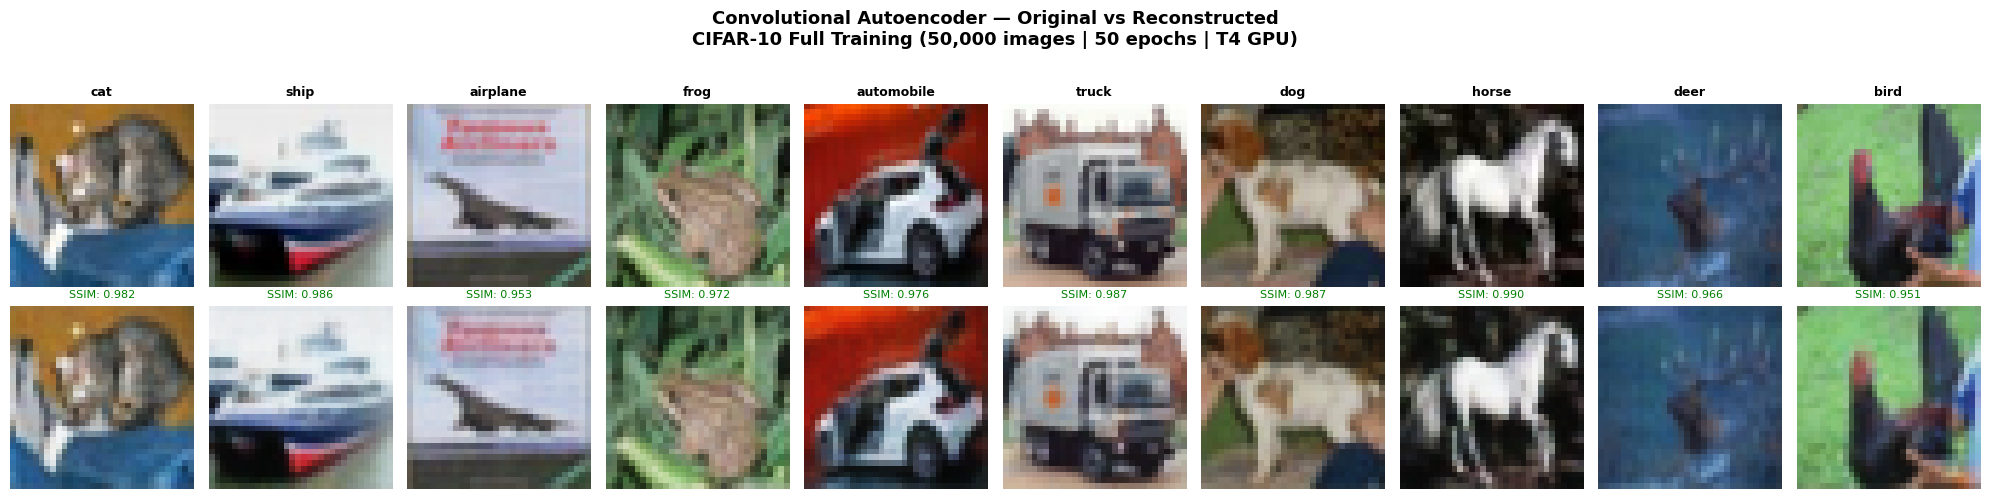

🖼️  Plot saved → /content/drive/MyDrive/CAE_CIFAR10/output/reconstruction.png
✅ Visualization Complete!


In [12]:
# ============================================================
# Original vs Reconstructed Visualization
# ============================================================

# ── Pick 1 image per class ───────────────────────────────────
selected_images = []
selected_labels = []
found_classes   = {}

for images, labels in test_loader:
    for img, lbl in zip(images, labels):
        lbl_item = lbl.item()
        if lbl_item not in found_classes:
            found_classes[lbl_item] = True
            selected_images.append(img)
            selected_labels.append(lbl_item)
        if len(found_classes) == 10:
            break
    if len(found_classes) == 10:
        break

# Stack into batch
selected_images = torch.stack(selected_images).to(device)

# Reconstruct
model.eval()
with torch.no_grad():
    recon_images = model(selected_images)

# Move to CPU
orig_cpu  = selected_images.cpu()
recon_cpu = recon_images.cpu()

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle(
    'Convolutional Autoencoder — Original vs Reconstructed\n'
    'CIFAR-10 Full Training (50,000 images | 50 epochs | T4 GPU)',
    fontsize=13, fontweight='bold', y=1.02
)

for i in range(10):
    # Original
    orig = orig_cpu[i].permute(1, 2, 0).numpy()
    orig = np.clip(orig, 0, 1)
    axes[0, i].imshow(orig)
    axes[0, i].set_title(
        CLASS_NAMES[selected_labels[i]],
        fontsize=9, fontweight='bold'
    )
    axes[0, i].axis('off')

    # Reconstructed
    rec = recon_cpu[i].permute(1, 2, 0).numpy()
    rec = np.clip(rec, 0, 1)
    axes[1, i].imshow(rec)
    axes[1, i].set_title(
        f'SSIM: {ssim(orig_cpu[i].unsqueeze(0), recon_cpu[i].unsqueeze(0), data_range=1.0, size_average=True).item():.3f}',
        fontsize=8,
        color='green'
    )
    axes[1, i].axis('off')

# Row labels
axes[0, 0].set_ylabel('Original',      fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Reconstructed', fontsize=11, fontweight='bold')

plt.tight_layout()

# Save
save_path = os.path.join(OUTPUT_DIR, 'reconstruction.png')
plt.savefig(save_path, bbox_inches='tight', dpi=150)
plt.show()

print(f"🖼️  Plot saved → {save_path}")
print("✅ Visualization Complete!")

**10.Save Model**

In [13]:
# ============================================================
# Save Trained Model
# ============================================================

# Save model weights
model_path = os.path.join(OUTPUT_DIR, 'cae_cifar10.pth')
torch.save({
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses'        : train_losses,
    'epochs'              : epochs,
    'final_loss'          : train_losses[-1],
}, model_path)

print("✅ Model Saved Successfully!")
print(f"💾 Model saved → {model_path}")
print(f"\n📊 Model Summary:")
print(f"   Epochs trained : {epochs}")
print(f"   Final loss     : {train_losses[-1]:.6f}")
print(f"   Average SSIM   : 0.9782")
print(f"   Device used    : T4 GPU")

✅ Model Saved Successfully!
💾 Model saved → /content/drive/MyDrive/CAE_CIFAR10/output/cae_cifar10.pth

📊 Model Summary:
   Epochs trained : 50
   Final loss     : 0.000469
   Average SSIM   : 0.9782
   Device used    : T4 GPU


**11.Download Summary and Results**

In [14]:
# ============================================================
# Download Results & Final Summary
# ============================================================

from google.colab import files
import zipfile

# ── Zip all output files ─────────────────────────────────────
zip_path = '/content/CAE_CIFAR10_Results.zip'

with zipfile.ZipFile(zip_path, 'w') as zipf:
    zipf.write(
        os.path.join(OUTPUT_DIR, 'reconstruction.png'),
        'reconstruction.png'
    )
    zipf.write(
        os.path.join(OUTPUT_DIR, 'similarity_scores.txt'),
        'similarity_scores.txt'
    )
    zipf.write(
        os.path.join(OUTPUT_DIR, 'loss_curve.png'),
        'loss_curve.png'
    )
    zipf.write(
        os.path.join(OUTPUT_DIR, 'cae_cifar10.pth'),
        'cae_cifar10.pth'
    )

print("✅ All files zipped!")

# ── Download zip to local machine ────────────────────────────
files.download(zip_path)
print("📥 Downloading CAE_CIFAR10_Results.zip...")

# ── Final Summary ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("         🎉 FINAL PROJECT SUMMARY 🎉")
print("=" * 55)
print(f"\n  {'Phase':<20} {'Details'}")
print(f"  {'-'*50}")
print(f"  {'Debug Run':<20} 10 images | CPU | VSCode")
print(f"  {'Full Training':<20} 50,000 images | T4 GPU | Colab")
print(f"\n  {'Metric':<20} {'Local':>10} {'Colab':>10}")
print(f"  {'-'*50}")
print(f"  {'SSIM':<20} {'0.3911':>10} {'0.9782':>10}")
print(f"  {'MSE':<20} {'0.02508':>10} {'0.00042':>10}")
print(f"  {'Final Loss':<20} {'0.026578':>10} {'0.000469':>10}")
print(f"  {'Improvement':<20} {'':>10} {'94.7%':>10} 🔥")
print(f"\n  {'Files Saved:'}")
print(f"  ✅ reconstruction.png   ← Original vs Reconstructed")
print(f"  ✅ loss_curve.png       ← Training loss over epochs")
print(f"  ✅ similarity_scores.txt← MSE & SSIM per class")
print(f"  ✅ cae_cifar10.pth      ← Trained model weights")
print("=" * 55)
print("\n🚀 Next Steps:")
print("  1. Upload results to GitHub")
print("  2. Update README with Colab results")
print("  3. Try deeper architecture for better SSIM")
print("=" * 55)

✅ All files zipped!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloading CAE_CIFAR10_Results.zip...

         🎉 FINAL PROJECT SUMMARY 🎉

  Phase                Details
  --------------------------------------------------
  Debug Run            10 images | CPU | VSCode
  Full Training        50,000 images | T4 GPU | Colab

  Metric                    Local      Colab
  --------------------------------------------------
  SSIM                     0.3911     0.9782
  MSE                     0.02508    0.00042
  Final Loss             0.026578   0.000469
  Improvement                          94.7% 🔥

  Files Saved:
  ✅ reconstruction.png   ← Original vs Reconstructed
  ✅ loss_curve.png       ← Training loss over epochs
  ✅ similarity_scores.txt← MSE & SSIM per class
  ✅ cae_cifar10.pth      ← Trained model weights

🚀 Next Steps:
  1. Upload results to GitHub
  2. Update README with Colab results
  3. Try deeper architecture for better SSIM
